# Introduction

The purpose of this notebook is to recreate the main experimental results from the paper: "Robust, multi-probe ptychographic neural networks via experimentally-grounded synthetic data".

Note that all experiment management/orchestration is abstracted/handled by the machine learning package MLFlow, while many aspects of model training is handled by Pytorch Lightning. Some helper functions have been created so you can view all results with minimal effort.

The main workhorse script of this notebook is inference.py, which will load a given model and benchmark it versus any data file that has been pre-processed via Ptychodus.

## Ptychodus Data Format

The data files linked from the mansucript originate in a variety of beamline output data formats (e.g. h5 files). They have had their units standardized to pixel units, as well as fixed diffraction image cropping size and extreme pixel value clipping. 

Each data file has the following relevant fields. You are safe to ignore the other ones not listed here:

- **diff3d**: Diffraction image file tensor of size [N, H, W], where N is # of images, H is image height, W is W width. In our case, H and W are both 64 x 64.

- **coords**: Scan position **x** coordinates normalized to pixel units. These are pixel units in the imaging/sample plane. Tensor is of size [N], where N is the # of images/scan positions

- **ycoords**: Scan position **y** coordinates normalized to pixel units. These are pixel units in the imaging/sample plane. Tensor is of size [N], where N is the # of images/scan positions

- **probeGuess**: Reconstructed probe from pty-chi. Is a complex-valued tensor of size [H, W], where H and W are the same size as the diffraction image, which is 64 pixels in this case.

- **objectGuess**: Reconstructed object from pty-chi. Is a complex-valued tensor of size [Ho, Wo], where Ho and Wo are arbitrary object dimensions which are not restricted to 64 pixels.



## Custom Ptychography Dataloader

PtychoPINN-torch requires inputting multiple overlapping diffraction patterns per input, which requires a slightly more special dataloader structure than what is typically required of a CNN/U-net based inference engine (i.e. 1 image in, 1 image out).

Additionally, the requirement of overlapping diffraction patterns balloons the memory requirement of the input tensors, which will quickly lead to out-of-memory errors when training on relatively large datasets.

We circumvent this by pre-computing all the groups of diffraction patterns and putting them in a memory map, alongside the associated coordinates. Only small mini-batches this memory map are moved to GPU during training, which incurs some speed penalty but is a trade-off we're willing to make.

We additionally have some specific configurations that can change the way in which our input data, including diffraction patterns and probe functions, are normalized/grouped. These configurations are included as MLflow artifacts and will automatically load once you try to load a specific model. This makes every training result fully reproducible as what you see in the manuscript.

## Configurations

There are several main configuration classes you can tinker with. You can load previous runs to see examples of what these class attribute values are, as well as inspect some of the example provided .json files which include modifications to the base configuration class default values. Look at ```config_params.py``` for additional details.

1. ```DataConfig```: This class contains all parameters associated with the dataloading process. This includes normalization, grouping, coordinate bounding, etc. One common error you may run into is that the grouping algorithm does not work properly. This can be relaxed by changing the ```x_bounds``` and ```y_bounds``` parameters to include fewer points (i.e. shrinking the range threshold), as well as shrinking the ```min_neighbor_distance``` parameter and increasing the ```max_neighbor_distance``` parameter. The ```C``` parameter describe show many images are included in each input. The baseline is 4 overlapping images, which is used for the manuscript. If you want a model without any overlaps (pure CDI model), you can set this to 1.

2. ```ModelConfig```: This class contains all parameters associated with the neural network portion of the model. There is almost nothing here that well be of interest except for ```cbam_encoder``` (CBAM module on encoder side), which is ```True``` for the majority of training runs. The loss function is also swappable via ```loss_function```, but we advise to keep it at Poisson, which is the default.

3. ```TrainingConfig```: This class contains all parameters associated with training. The number of devices need to be modified based on your available resources. 1 is for 1 GPU, 2 is for 2, so on. Other parameters of interest could be ```epochs```, ```batch_size``` (recomended at 16) and ```fine_tune_epochs``` (can be 0 if no fine-tuning desired). Additionally, MLFlow notes can be set here, which will make it easier to identify/find your training runs through the MLflow api.

4. ```InferenceConfig```: These are inference-specific parameters. Only relevant parameters are ```batch_size```, which may need to be adjusted depending on available GPU memory (reduce if getting OOM errors), and ```window_size```, which trims the outer edges of the image. This is particularly relevant because some of the neural net predictions on the outer image edges will have extremely disjoint amplitude/phase values, resulting in unphysical contrast differences from the main image.

5. ```DatagenConfig```: This is only relevant if synthetic data is being used to train a model. This parameter will allow you to also re-create the synthetic data generation process (not the seed, unfortunately since generation is random) used to train a specific model. This matters if you're trying to differentiate two models that have been trained on the same probe, but different synthetic objects such as dead_leaves and blurred_white_noise.

# Experiment Loading

MLFlow provides several main methods of loading an experiment. You can sort through notes and additional custom labels in order to find a run of interest, or alternatively provide a unique run identifier code that is associated with a specific run. For this manuscript, we provide a dictionary where the keys are descriptive of the contents of the model, while the values are the ids associated with each model. 

All model/experiment artifacts associated with a specific training run are contained in a folder labelled by the run_id, which also contains a config.yaml file. This config.yaml file points to the directory of the artifacts, and must be changed depending on your installation path for this repository. Ensure that you run ```initialize.py``` found in the root directory of the repository to fix this path automatically. 

Note that the config.yaml file within each specific run folder, found within the mlruns

We have provided some abstracted function cals that will allow you to load a model and infer on a given dataset. We will also provide examples of inferences that you can do.

### Dictionary with experiment-id associations

In [1]:
model_ids = {
    #Dead Leaves Synthetic (Figure 2), Single experiment transfer
    'PS_TP1': 'f637381fd7fe49158bb0ed2e7a28ca45',
    'PS_TP2': '6fb4668f21e44e0b80056f64fdfedf01',
    'PS_IC1': '345aa234e8f34935af11c3ebed167448',
    'PS_IC2': '06822d7239504a93ae0f7a6c4577cdc8',
    'PS_NCM': '0908cd113f774d15802f41e40b3a51e2',
    'PS_FLY1': '3d2ca583357c43baa6ab17519d500355',
    'PS_W': '74ba23396c4042afb1751afe9fa87520',
    'PS_LFP': '1cda8280703748fabba173f747fc4103',

    #Experiment-only (Figure 2), Single experiment transfer
    #To-DO (remove later) copy to data directory
    'PE_TP1': 'c86ba4cc6d424a8fb1370bcfa87d967c',
    'PE_TP2': '3dcc4ce0423c46f6bab529294886f453',
    'PE_IC1': 'b1f8f06f9dee41e48e0323d295e0a5d3',
    'PE_IC2': 'e09fa3d8b48e406aa7c9ff78e34f7782',
    'PE_NCM': '293d4107954d4d11832fe979e6045229',
    'PE_FLY1': '4911939f91d147348f450ec1d78811dd',
    'PE_W': '3360765d399443d0a758e9667c8455b5',
    'PE_LFP': 'aee5ab755d8e4e558c1f328491adb0fb',

    #Multi-model (Figure 3) Single probe/baselines
    #These are the same, you just switch out the evaluation (test) dataset.
    'Single_W': 'bec5909f8c7d407dbdcdc24357495239',
    'Single_LFP': 'e4a5907f060c4af1adb9005a4fc1c51e',
    'Single_FLY1': '9c87bda4384f42a9ad8f7fa0bcc6ea5b',
    'Single_IC2': '5c668cbdb3244e92acd8cb1d682234df',

    #Multi-model (Figure 3) Dual probe
    'W_LFP': 'd3dc54d3897941e89bc16c85b82fba44',
    'W_FLY1': 'cb2e664b3001486ba1047936d0b4a533',
    'W_IC2': '92f5a0518ea641adb8a75e02242c390e',
    'LFP_FLY1': 'f7c72e4058994eea9e9c43ffe7e3b278',
    'LFP_IC2': 'f7c72e4058994eea9e9c43ffe7e3b278',
    'FLY1_IC2': '40f07429768142c5b4d7b57f5c072862',

    #Multi-model (Figure 3) Unified
    'Unified': 'f6ce8d9583164c84955fc6209c340e04',

    #Synthetic objects (Figure 4)
    # Dead leaves
    "DL_W": "74ba23396c4042afb1751afe9fa87520",
    "DL_FLY1": "3d2ca583357c43baa6ab17519d500355",
    "DL_IC2": "6fb4668f21e44e0b80056f64fdfedf01",
    "DL_LFP": "1cda8280703748fabba173f747fc4103",

    # Procedural
    "PR_W": "ed7cabe320b94e82a2a8c13b519abc6d",
    "PR_FLY1": "11ff4f97061f4554b831c45caa40f495",
    "PR_IC2": "04106a3750184a2dbe544cc2c8c2f857",
    "PR_LFP": "1aaf4df1f3a5440da898667953dd11f3",
    
    # Blurred White Noise
    "BWN_W": "42d9fb49f2c94a44b0f03b7f221cab8f",
    "BWN_FLY1": "1c5528183d834c299e2d43e535fb8cf8",
    "BWN_IC2": "0c975e1328e64f7898abb6d94973bbec",
    "BWN_LFP": "0248c08bb3c04004a6672a201f9a3a2d",

    #Simplex
    "SN_W": "7c0b74ecf2d54198acea22aee60fdfc2",
    "SN_FLY1": "db698d0b702348ae8f33bf44e0d1573b",
    "SN_IC2": "c98fefc6252e494db5f0ce5155904333",
    "SN_LFP": "12ce5db7c1564fd7a5fed78704b0c010"
}

experiment_files = {
    'TP2': 'data/TP2',
    'TP1': 'data/TP1',
    'IC1': 'data/IC1',
    'IC2': 'data/IC2',
    'NCM': 'data/NCM',
    'FLY1': 'data/FLY1',
    'W': 'data/W',
    'LFP': 'data/LFP'
}

window_sizes = {
    'TP2': 40,
    'TP1': 20,
    'IC1': 20,
    'IC2': 20,
    'NCM': 20,
    'FLY1': 10,
    'W': 20,
    'LFP': 20
}

# Beginning reconstructions

Now we'll import some useful abstracted functions that allow us to generate reconstructions of our results. Feel free to look in ```analysis.py``` for additional details.

The main workhorse functions are found in ```reassembly.py```. In short, we are doing the following:

1. Loading model artifacts from the MLFlow model directory
2. Creating a dataloader from the specified data path, which leads to a .npz file formatted by Ptychodus
3. Performing inference on the dataloader in batches (this is optimized for multi-gpu)
4. Assembling the infered object patches (which doesn't take much overhead).
5. Getting the finished reconstruction alongside ground truth image

Note that this process does not explicitly use the probe, as the probe is only used in training to condition the neural network.

Note that we have a pretty conservative batch size for inference (around 500), which is much less than what we benchmarked on in the manuscript (3000). The inference script will parallelize by auto-detecting GPUs, and ideally should be run on a machine with access to at least 1 GPU.

In [2]:
import importlib
import ptychopinn_torch.notebooks.analysis
importlib.reload(ptychopinn_torch.notebooks.analysis)
import os
from ptychopinn_torch.notebooks.analysis import generate_gt_and_recon, plot_object, preprocess_and_calculate_frc, calculate_threshold_frc
import numpy as np
import matplotlib.pyplot as plt


/home/zhong.zheng/miniforge3/envs/ptychopinn_torch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
id = 'W'

gt, recon = generate_gt_and_recon(experiment_files[id], 'BWN_W', model_ids,
                                  window_sizes)



file:/home/zhong.zheng/PtychoPINN/mlruns
Creating dataset...
Calculating dataset length with coordinate bounds...
For file data/W/supervised_pinn_cnm.npz, maximum x_range is (33.04172515869142, 203.9582748413086), yrange is (33.0417251586895, 203.9582748413105)
Creating memory mapped tensor dictionary...
Memory map length: 20449
Memory map creation time: 0.0023305416107177734


/home/zhong.zheng/miniforge3/envs/ptychopinn_torch/lib/python3.10/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


Populating memory map for dataset 0
Estimated rows for dataset: 20449
Building KDTree for 25921 points...
Processing 20449 potential central points...
Finished quadrant neighbor processing. Found 20449 valid C=4 groups.
Actual grouped rows for dataset: 20449
Non-diffraction memory map write time: 3.8255975246429443
Getting normalization coefficients...
Batch rms factor is tensor([[[[0.0002]]]])
Diffraction memory map write time: 1.4557127952575684


/home/zhong.zheng/miniforge3/envs/ptychopinn_torch/lib/python3.10/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.Byte

[PtychoDataset Rank 0] Initialization successful. Dataset length: 20449.
Beginning reconstruction...
CUDA requested by config but unavailable; using CPU.


2026/06/08 15:02:25 WARNING mlflow.pytorch: Stored model version '2.5.1' does not match installed PyTorch version '2.4.0'


Reconstructing image...
Using single GPU: cpu
Canvas size: (192, 192), Max offset: 80
Batch 1/40: 2.294s (inference: 1.894s, assembly: 0.046s, efficiency: 41.0x)
Batch 2/40: 1.600s (inference: 1.562s, assembly: 0.037s, efficiency: 41.8x)
Batch 3/40: 1.530s (inference: 1.491s, assembly: 0.038s, efficiency: 38.8x)
Batch 4/40: 1.755s (inference: 1.690s, assembly: 0.064s, efficiency: 26.6x)
Batch 5/40: 1.613s (inference: 1.579s, assembly: 0.033s, efficiency: 48.1x)
Batch 6/40: 2.209s (inference: 1.675s, assembly: 0.041s, efficiency: 40.6x)
Batch 7/40: 1.687s (inference: 1.654s, assembly: 0.033s, efficiency: 50.0x)
Batch 8/40: 1.809s (inference: 1.769s, assembly: 0.039s, efficiency: 44.8x)
Batch 9/40: 1.644s (inference: 1.604s, assembly: 0.040s, efficiency: 40.4x)
Batch 10/40: 1.851s (inference: 1.808s, assembly: 0.042s, efficiency: 43.3x)
Batch 11/40: 2.159s (inference: 1.630s, assembly: 0.033s, efficiency: 49.6x)
Batch 12/40: 1.917s (inference: 1.867s, assembly: 0.049s, efficiency: 38.0x)

Image saved as figures/Reconstruction.svg


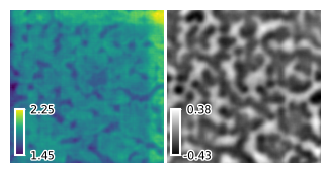

Image saved as figures/Ground Truth.svg


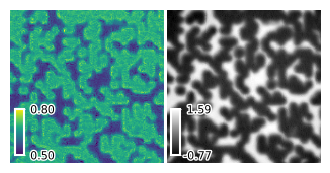

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f0528138910>)

In [5]:
# Note that there may be some display distortions for these images. Save these images in a directory if you want to see a high quality version

# Note, if using the Unified model with FLY1, use the following settings for a more proper phase representation
# recon_phase = np.angle(recon)
# recon_phase[recon_phase > 2.2] = 2.2
# recon = np.abs(recon) * np.exp(1j * recon_phase)

plot_object(recon, save_path = 'figures', save_name = 'Reconstruction')
plot_object(gt, save_path = 'figures', save_name = 'Ground Truth')

Starting FRC pre-processing...
Step 3: Final phase matching of img1 to img2.
  _match_phases: a0=0.1968, ax_fit=0.1020, ay_fit=0.0942
  _match_phases: phase_ramp min=0.0987, max=0.2949, mean=0.1968
Step 4: Applying soft-edge taper (20 px).
FRC pre-processing complete.
performed by index method
performed by index method
performed by index method


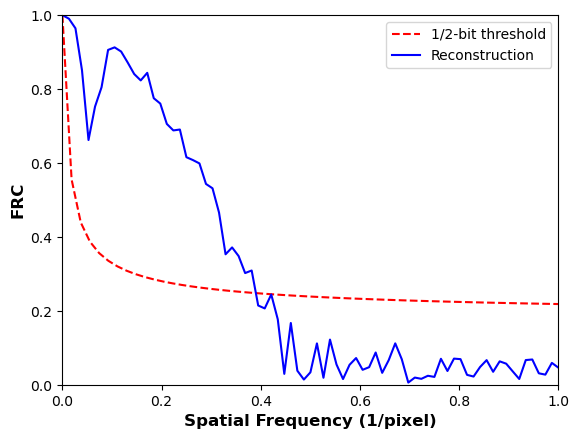

In [6]:
# Calculate FRC
FR_curve, x_FR, FR_AUC = preprocess_and_calculate_frc(gt, recon)

x_T, T_curve = calculate_threshold_frc(x_FR)

plt.plot(x_T, T_curve, label='1/2-bit threshold', linestyle='--', color='red')
plt.plot(x_FR, FR_curve, label = 'Reconstruction', linestyle = '-', color = 'blue')
    
plt.xlabel('Spatial Frequency (1/pixel)', fontweight = 'bold', fontsize=12)
plt.ylabel('FRC', fontweight = 'bold', fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()

# Synthetic object simulations and inference

Here we can simulate a synthetic object using some of the same machinery used in the ```train_full.py``` function.

We will have to explicitly modify some attributes of the default config settings.

Note that if you want to do a full synthetic object training run, please see ```ptychopinn_torch/train_full.py for details```.

If you do a full training run, note that we'll be loading a set of custom configs alongside creating a new synthetic data directory, which will contain the simulated diffraction data alongside the "ground truth" synthetic objects. In order to select the probe used to simulate diffraction data, we will simply provide the data directory corresponding to the specific experiment, using the same dictionary as above.

If we want to train on multiple probes, the best practice is to move all the npz files under a single directory and pass that to ```train_full.py```. 

Nevertheless, we'll simply be simulating different synthetic objects below so you can see what they look like

In [ ]:
import ptychopinn_torch.train_full
importlib.reload(ptychopinn_torch.train_full)
from ptychopinn_torch.train_full import prepare_data, load_all_configs
from ptychopinn_torch.datagen.datagen import simulate_synthetic_objects
from ptychopinn_torch.config_params import DataConfig, DatagenConfig, update_existing_config

Creating objects for class: blurred_white_noise


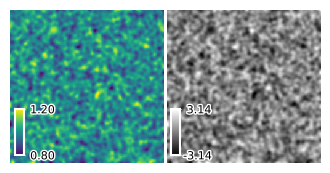

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f93b3f55a50>)

In [ ]:
#Prepare data
config_path = ''
ptycho_dir = experiment_files['TP2']
# configs, dgen_config_replace = load_all_configs(ptycho_dir, config_path)
# data_config, model_config, training_config, inference_config, datagen_config = configs

#Defining configurations
data_config = DataConfig()
datagen_config = DatagenConfig()

#Substituting some configurations
#Here are the list of configurations taken from config_params for your reference:
#['procedural', 'polyhedra','dead_leaves','white_noise',
#   'simplex_noise','blurred_white_noise']
#Substitute the value for object_class with one of the supported synthetic data classes
datagen_config_replace = {
    'object_class': 'blurred_white_noise',
    'objects_per_probe': 1,
    'probe_paths': [ptycho_dir]
}

update_existing_config(datagen_config, datagen_config_replace)

#Some metadata stuff that's usually handled in train_full.py
obj_arg = {}
probe_arg = {}

# Create synthetic object

print(f"Creating objects for class: {datagen_config.object_class}")
image_size = datagen_config.image_size
synthetic_obj_list = simulate_synthetic_objects(image_size, data_config, datagen_config.objects_per_probe,
                                                                datagen_config.object_class, obj_arg)

plot_object(synthetic_obj_list[0])